### 1. Initializing the Deep Learning Ensemble
To achieve autonomous inference, we load the trained weights for all models into the GPU memory simultaneously. 
*   **YOLOv8:** Object Detection / Localization
*   **U-Net:** Semantic Segmentation / Morphological Feature Extraction
*   **EfficientNet-B0:** Texture / Deep Representation Extraction
*   **Super Ensemble (XGB+LGBM+RF):** Meta-Learner / Final Clinical Diagnosis

In [5]:
import cv2
import torch
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb_lib
from sklearn.ensemble import RandomForestClassifier
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
import segmentation_models_pytorch as smp
from ultralytics import YOLO
import torch.nn as nn
import joblib
import scipy.stats as sts
import skimage.feature as feature
from scipy.stats import mode
import ast

In [6]:
print("Loading all AI Models into Memory...\n")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Loading all AI Models into Memory...



In [7]:
class CervicalCancerSuperEnsemble:
    def __init__(self, xgb, lgb, rf):
        self.xgb = xgb
        self.lgb = lgb
        self.rf = rf
        self.xgb_feats = xgb.feature_names_in_
        self.lgb_feats = lgb.feature_names_in_
        self.rf_feats = rf.feature_names_in_

    def predict_proba(self, X_scaled):
        p_xgb = self.xgb.predict_proba(X_scaled[self.xgb_feats])
        p_lgb = self.lgb.predict_proba(X_scaled[self.lgb_feats])
        p_rf = self.rf.predict_proba(X_scaled[self.rf_feats])
        return (p_xgb + p_lgb + p_rf) / 3.0

    def predict(self, X_scaled):
        pred_xgb = self.xgb.predict(X_scaled[self.xgb_feats])
        pred_lgb = self.lgb.predict(X_scaled[self.lgb_feats])
        pred_rf = self.rf.predict(X_scaled[self.rf_feats])
        stacked = np.stack([pred_xgb, pred_lgb, pred_rf], axis=1)
        return mode(stacked, axis=1, keepdims=False).mode

# 1. Load YOLOv8
yolo_model = YOLO(r"..\runs\detect\sipakmed_yolo\weights\best.pt")

# 2. Load U-Net
unet_model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=3).to(device)
unet_model.load_state_dict(torch.load(r"..\trained_models\unet\unet_sipakmed.pth", map_location=device))
unet_model.eval()

# 3. Load EfficientNet
cnn_model = models.efficientnet_b0()
cnn_model.classifier[1] = nn.Linear(cnn_model.classifier[1].in_features, 5)
cnn_model.load_state_dict(torch.load(r"..\trained_models\cnn\efficientnet_sipakmed.pth", map_location=device))
cnn_model = cnn_model.to(device)
cnn_model.eval()

# 4. Load Super Ensemble and Scaler
super_ai = joblib.load(r"..\trained_models\Super_Ensemble_Model.pkl")
scaler = joblib.load(r"..\trained_models\Super_Ensemble_Scaler.pkl")
print("All Models Loaded Successfully!")

C:\Users\parth\AppData\Local\Temp\ipykernel_21416\88260995.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_model.load_state_dict(torch.load(r"..\trained_models\une

All Models Loaded Successfully!


In [8]:
# Standard settings
cnn_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
class_names = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']
# We need the exact column names expected by the scaler
expected_cols = scaler.feature_names_in_

In [9]:
def extract_all_features(img_name, true_class, mask, cell_rgb, probs):
    cell_rgb = cv2.resize(cell_rgb, (mask.shape[1], mask.shape[0]))
    nuc_mask = (mask == 2).astype(np.uint8) * 255
    cyto_mask = (mask == 1).astype(np.uint8) * 255
    
    nuc_area = float(np.sum(mask == 2))
    cyt_area = float(np.sum(mask == 1))
    total_area = cyt_area + nuc_area
    nc_ratio = nuc_area / cyt_area if cyt_area > 0 else 0.0
    
    nuc_perimeter = nuc_circularity = nuc_eccentricity = aspect = solidity = extent = centroid_dist = 0.0
    hu = [0.0] * 7
    fd_mag = [0.0] * 5
    
    contours, _ = cv2.findContours(nuc_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        nuc_perimeter = float(cv2.arcLength(largest_contour, True))
        if nuc_perimeter > 0:
            nuc_circularity = 4 * np.pi * (nuc_area / (nuc_perimeter ** 2))
        if len(largest_contour) >= 5:
            (x, y), (MA, ma), angle = cv2.fitEllipse(largest_contour)
            if MA > 0:
                nuc_eccentricity = ma / MA
                aspect = MA / ma
        hull = cv2.convexHull(largest_contour)
        hull_area = cv2.contourArea(hull)
        if hull_area > 0: solidity = nuc_area / hull_area
        x, y, w, h = cv2.boundingRect(largest_contour)
        if w * h > 0: extent = nuc_area / (w * h)
        hu = cv2.HuMoments(cv2.moments(largest_contour)).flatten().tolist()
        M_n = cv2.moments(largest_contour)
        if M_n['m00'] != 0:
            cx_n = M_n['m10'] / M_n['m00']
            cy_n = M_n['m01'] / M_n['m00']
            cyto_contours, _ = cv2.findContours(cyto_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(cyto_contours) > 0:
                c_cnt = max(cyto_contours, key=cv2.contourArea)
                M_c = cv2.moments(c_cnt)
                if M_c['m00'] != 0:
                    cx_c = M_c['m10'] / M_c['m00']
                    cy_c = M_c['m01'] / M_c['m00']
                    centroid_dist = np.sqrt((cx_n - cx_c)**2 + (cy_n - cy_c)**2)
        pts = largest_contour.squeeze()
        if pts.ndim == 2 and len(pts) > 0:
            complex_pts = pts[:, 0] + 1j * pts[:, 1]
            fd = np.fft.fft(complex_pts)
            fd_mag = np.abs(fd[:5]).tolist()
            while len(fd_mag) < 5: fd_mag.append(0.0)

    gray = cv2.cvtColor(cell_rgb, cv2.COLOR_BGR2GRAY)
    gray_nuc = cv2.bitwise_and(gray, gray, mask=nuc_mask)
    mean_int, stddev = cv2.meanStdDev(gray, mask=nuc_mask)
    chromatin_variance = float(stddev[0][0] ** 2) if stddev is not None else 0.0
    
    nuc_pixels = gray_nuc[gray_nuc > 0]
    if len(nuc_pixels) > 0:
        nuc_mean = np.mean(nuc_pixels)
        nuc_median = np.median(nuc_pixels)
        nuc_std = np.std(nuc_pixels)
        nuc_skew = sts.skew(nuc_pixels)
        nuc_kurtosis = sts.kurtosis(nuc_pixels)
        hist, _ = np.histogram(nuc_pixels, bins=256, range=(0, 255), density=True)
        nuc_entropy = sts.entropy(hist + 1e-12)
        glcm = feature.graycomatrix(gray_nuc, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
        glcm_contrast = feature.graycoprops(glcm, 'contrast').mean()
        glcm_correlation = feature.graycoprops(glcm, 'correlation').mean()
        glcm_energy = feature.graycoprops(glcm, 'energy').mean()
        glcm_homogeneity = feature.graycoprops(glcm, 'homogeneity').mean()
        lbp = feature.local_binary_pattern(gray_nuc, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, 10), density=True)
        lbp_hist = lbp_hist.tolist()
    else:
        nuc_mean = nuc_median = nuc_std = nuc_skew = nuc_kurtosis = nuc_entropy = 0.0
        glcm_contrast = glcm_correlation = glcm_energy = glcm_homogeneity = 0.0
        lbp_hist = [0.0] * 9

    nuc_rgb = cell_rgb[nuc_mask.astype(bool)]
    if len(nuc_rgb) > 0:
        R = nuc_rgb[:, 2].astype(float)
        G = nuc_rgb[:, 1].astype(float)
        B = nuc_rgb[:, 0].astype(float)
        rg_ratio = R.mean() / (G.mean() + 1e-6)
        rb_ratio = R.mean() / (B.mean() + 1e-6)
        gb_ratio = G.mean() / (B.mean() + 1e-6)
    else:
        rg_ratio = rb_ratio = gb_ratio = 0.0

    features = {
        'Nuc_Area': nuc_area, 'Cyt_Area': cyt_area, 'Total_Area': total_area, 'NC_Ratio': nc_ratio,
        'Nuc_Perimeter': nuc_perimeter, 'Nuc_Circularity': nuc_circularity, 'Nuc_Eccentricity': nuc_eccentricity,
        'Nucleus_Aspect': aspect, 'Nucleus_Solidity': solidity, 'Nucleus_Extent': extent, 'Centroid_Dist': centroid_dist,
        'Hu_1': hu[0], 'Hu_2': hu[1], 'Hu_3': hu[2], 'Hu_4': hu[3], 'Hu_5': hu[4], 'Hu_6': hu[5], 'Hu_7': hu[6],
        'Fourier_1': fd_mag[0], 'Fourier_2': fd_mag[1], 'Fourier_3': fd_mag[2], 'Fourier_4': fd_mag[3], 'Fourier_5': fd_mag[4],
        'Chromatin_Variance': chromatin_variance, 'Nuc_Mean': nuc_mean, 'Nuc_Median': nuc_median, 'Nuc_Std': nuc_std,
        'Nuc_Skew': nuc_skew, 'Nuc_Kurtosis': nuc_kurtosis, 'Nucleus_Entropy': nuc_entropy,
        'GLCM_Contrast': glcm_contrast, 'GLCM_Correlation': glcm_correlation, 'GLCM_Energy': glcm_energy, 'GLCM_Homogeneity': glcm_homogeneity,
        'LBP_0': lbp_hist[0], 'LBP_1': lbp_hist[1], 'LBP_2': lbp_hist[2], 'LBP_3': lbp_hist[3], 'LBP_4': lbp_hist[4], 
        'LBP_5': lbp_hist[5], 'LBP_6': lbp_hist[6], 'LBP_7': lbp_hist[7], 'LBP_8': lbp_hist[8],
        'RG_Ratio': rg_ratio, 'RB_Ratio': rb_ratio, 'GB_Ratio': gb_ratio,
        'Prob_0': probs[0], 'Prob_1': probs[1], 'Prob_2': probs[2], 'Prob_3': probs[3], 'Prob_4': probs[4]
    }
    return features


1. YOLO is scanning the image for cells...
YOLO found 10 cells! Cropping them now...


e:\SIPaKMeD\sipakmed_env\lib\site-packages\xgboost\core.py:751: UserWarning: [20:36:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


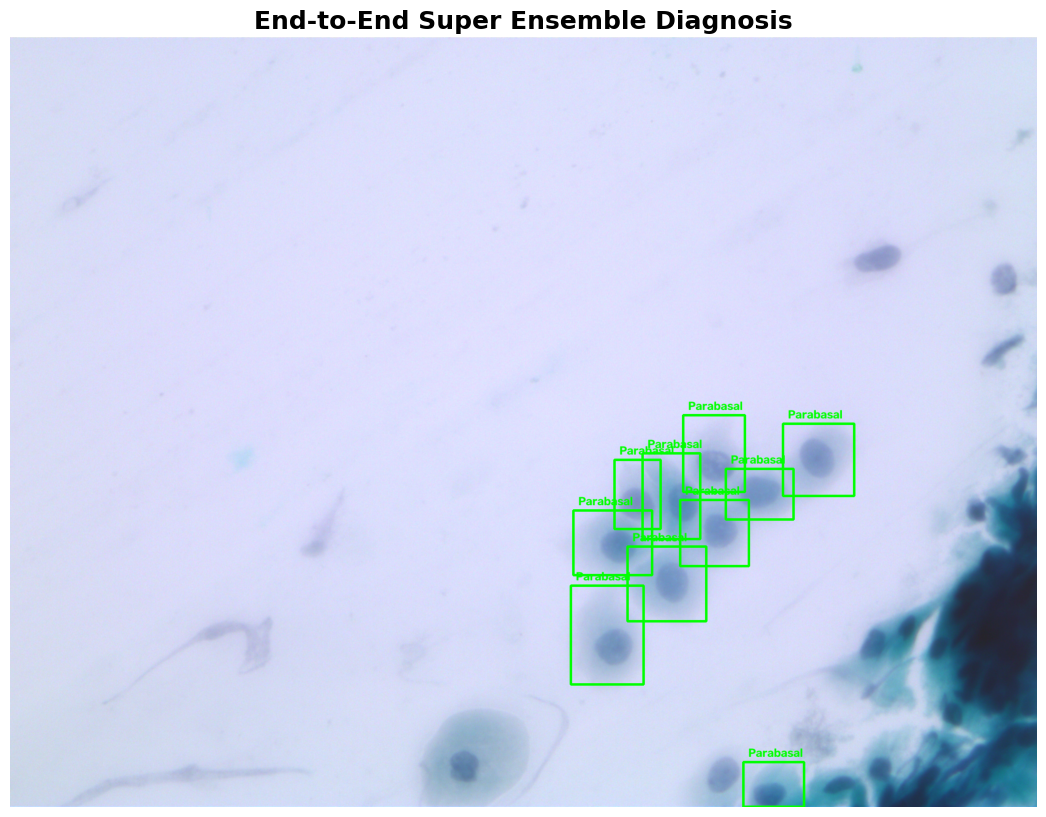

In [ ]:
# --- THE END TO END PIPELINE --- (SUPER ENSEMBLE)
test_image_path = r"..\Dataset\im_Parabasal\im_Parabasal\106.bmp" 
original_img = cv2.imread(test_image_path)
display_img = original_img.copy()

print("1. YOLO is scanning the image for cells...")
results = yolo_model(original_img, verbose=False)[0]

cells_to_process = []
if len(results.boxes) == 0:
    print("YOLO found 0 boxes! Assuming this is ALREADY a cropped image.")
    h, w, _ = original_img.shape
    cells_to_process.append((0, 0, w, h, original_img))
else:
    print(f"YOLO found {len(results.boxes)} cells! Cropping them now...")
    for box in results.boxes.data.tolist():
        x1, y1, x2, y2, confidence, _ = box
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        cell_crop = original_img[y1:y2, x1:x2]
        if cell_crop.size > 0:
            cells_to_process.append((x1, y1, x2, y2, cell_crop))
            
# --- PROCESS EVERY CELL WE FOUND ---
for x1, y1, x2, y2, cell_crop in cells_to_process:
    cell_rgb = cv2.cvtColor(cell_crop, cv2.COLOR_BGR2RGB)
    
    # 2. Get U-Net Mask
    unet_input = cv2.resize(cell_rgb, (128, 128)).transpose(2, 0, 1).astype('float32') / 255.0
    unet_tensor = torch.tensor(unet_input).unsqueeze(0).to(device)
    with torch.no_grad():
        mask = torch.argmax(unet_model(unet_tensor), dim=1).squeeze().cpu().numpy()
    
    # 3. Get EfficientNet Probabilities
    pil_img = Image.fromarray(cell_rgb)
    cnn_tensor = cnn_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.nn.functional.softmax(cnn_model(cnn_tensor), dim=1).squeeze().cpu().numpy()
        
    # 4. Extract all 51 features
    features_dict = extract_all_features("test", -1, mask, cell_crop, probs)
    
    # 5. Prepare Data for Super Ensemble (ensure exact column order)
    features_df = pd.DataFrame([features_dict])
    features_df = features_df[expected_cols] # Align columns with scaler
    features_scaled = scaler.transform(features_df)
    features_scaled_df = pd.DataFrame(features_scaled, columns=expected_cols)
    
    # 6. SUPER ENSEMBLE DIAGNOSIS (Hard Majority Vote)
    final_class_id = super_ai.predict(features_scaled_df)[0]
    final_diagnosis = class_names[final_class_id]
    
    # 7. Draw the bounding box and diagnosis
    cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    text_y = y1 - 10 if y1 > 30 else y1 + 30
    cv2.putText(display_img, final_diagnosis, (x1 + 10, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    
# Show the final result!
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("End-to-End Super Ensemble Diagnosis", fontsize=18, fontweight='bold')
plt.show()